In [1]:
from tvbo import Dynamics, SimulationExperiment

# Pendulum System
dynamics_yaml = """
name: PendulumSystem
parameters:
    c:
        value: 0.001
        unit: 1/ms
    omega0:
        value: 0.01
        unit: rad/ms
    L:
        value: 1.0
        unit: m

state_variables:
    theta:
        unit: rad
        initial_value: 1.0
        equation:
            rhs: omega
    omega:
        unit: rad/ms
        initial_value: 0.0
        equation:
            rhs: -c*omega - omega0**2 * sin(theta)
"""

pendulum = SimulationExperiment(
    dynamics=Dynamics.from_string(dynamics_yaml),
)
results = pendulum.run(duration=5_000)
results


STEP 1: Running simulation...
  Simulation period: 5000.0 ms, dt: 0.01220703125 ms
  Transient period: 0.0 ms
  Simulation complete.

Experiment complete.


```
Experiment
└── integration
        data: (409600, 2, 1)
```

In [2]:
results.integration.data

<xarray.DataArray (time: 409600, variable: 2, node: 1)> Size: 7MB
array([[[ 9.99999994e-01],
        [-1.02717999e-06]],

       [[ 9.99999975e-01],
        [-2.05434744e-06]],

       [[ 9.99999944e-01],
        [-3.08150232e-06]],

       ...,

       [[ 4.37768547e-02],
        [ 6.47587519e-04]],

       [[ 4.37847595e-02],
        [ 6.47526188e-04]],

       [[ 4.37926635e-02],
        [ 6.47464848e-04]]], shape=(409600, 2, 1))
Coordinates:
  * time      (time) float64 3MB 0.0 0.01221 0.02441 ... 5e+03 5e+03 5e+03
  * variable  (variable) <U5 40B 'theta' 'omega'
Dimensions without coordinates: node

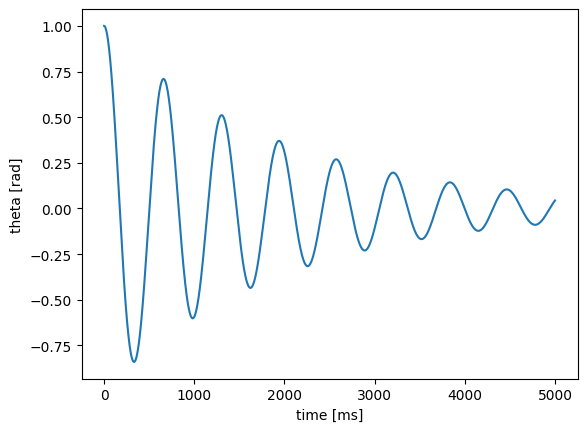

In [3]:
results.integration.sel(variable='theta').plot()

## Derived Variables

In [4]:
from tvbo.datamodel.schema import DerivedVariable
pendulum.dynamics.derived_variables["x"] = DerivedVariable(
    name="x",
    equation={"rhs": "L * sin(theta)"},
    unit="m",
    description="X coordinate of the pendulum bob",
)
pendulum.dynamics.derived_variables["y"] = DerivedVariable(
    name="y",
    equation={"rhs": "-L * cos(theta)"},
    unit="m",
    description="Y coordinate of the pendulum bob",
)

In [5]:
pendulum.dynamics.derived_variables

{'x': DerivedVariable({
   'name': 'x',
   'description': 'X coordinate of the pendulum bob',
   'equation': Equation({'rhs': 'L * sin(theta)', 'latex': False}),
   'unit': UnitEnum(text='m', description='Metre', meaning='http://qudt.org/vocab/unit/M'),
   'conditional': False
 }),
 'y': DerivedVariable({
   'name': 'y',
   'description': 'Y coordinate of the pendulum bob',
   'equation': Equation({'rhs': '-L * cos(theta)', 'latex': False}),
   'unit': UnitEnum(text='m', description='Metre', meaning='http://qudt.org/vocab/unit/M'),
   'conditional': False
 })}


STEP 1: Running simulation...
  Simulation period: 5000.0 ms, dt: 0.01220703125 ms
  Transient period: 0.0 ms
  Simulation complete.

Experiment complete.


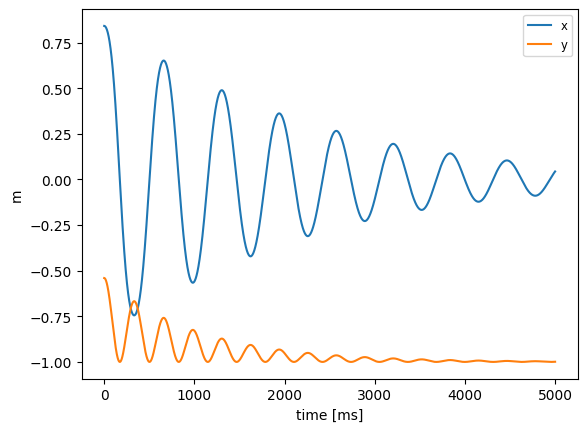

In [9]:
res2 = pendulum.run()

res2.integration.sel(variable=["x", "y"]).plot(type='vector_field')